# Physiological Signal Correlations

## Load Data

In [1]:
# misc directory is at the same level as scan directory, 
# so we need to change the current working directory to the root directory
# ONLY RUN THIS CELL ONCE

import os
os.chdir(os.path.dirname(os.getcwd()))

In [2]:
from typing import List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scan.io.load import DatasetLoad
from scipy.stats import rankdata

from main import (
    _concat_bootstrap_samples, 
    _generate_bootstrap_samples, 
    _physio_average
)

# load all phsyio siginals in dataset and concatenate
loader = DatasetLoad(
    'vanderbilt'
)
data, _ = loader.load(
    physio_high_pass=True, 
    func_high_pass=True,
    concat=False
)


260717-21:12:46,405 nipype.utils WARNING:
	 A newer version (1.11.0) of nipy/nipype is available. You are using 1.8.6


/Users/tbolt/Desktop/Research/SCAN/scan_physio/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading scan: subj: 02 ses: 01
loading scan: subj: 03 ses: 01
loading scan: subj: 04 ses: 02
loading scan: subj: 05 ses: 01
loading scan: subj: 07 ses: 01
loading scan: subj: 08 ses: 01
loading scan: subj: 09 ses: 01
loading scan: subj: 09 ses: 02
loading scan: subj: 10 ses: 01
loading scan: subj: 10 ses: 02
loading scan: subj: 13 ses: 01
loading scan: subj: 14 ses: 01
loading scan: subj: 14 ses: 02
loading scan: subj: 15 ses: 02
loading scan: subj: 18 ses: 01
loading scan: subj: 18 ses: 02
loading scan: subj: 19 ses: 02
loading scan: subj: 20 ses: 01
loading scan: subj: 20 ses: 02
loading scan: subj: 23 ses: 01
loading scan: subj: 24 ses: 01
loading scan: subj: 25 ses: 01
loading scan: subj: 25 ses: 02
loading scan: subj: 26 ses: 01
loading scan: subj: 27 ses: 02
loading scan: subj: 29 ses: 01
loading scan: subj: 29 ses: 02
loading scan: subj: 32 ses: 01
loading scan: subj: 33 ses: 01
loading scan: subj: 33 ses: 02
loading scan: subj: 36 ses: 01
loading scan: subj: 37 ses: 01
loading 

In [3]:
# get average of emg and eog channels
eog_mean, emg_mean = _physio_average(data, concat=False)
data['physio']['eog_mean'] = eog_mean
data['physio']['emg_mean'] = emg_mean

# get global signal
data['physio']['global_signal'] = [
    func.mean(axis=1)
    for func in data['func']
]

In [4]:
from scipy.io import loadmat

sleep_stages_all = []
for subj_ses in loader.iter:    
    # frametimes = np.linspace(0, (n_scans - 1) * t_r, n_scans)
    # load sleep stages
    sleep_fp = f"data/vanderbilt/sleep/vcon{subj_ses[0]}-scan{subj_ses[1]}_eeg_vsleep.mat"
    sleep_data = loadmat(sleep_fp, squeeze_me=True)
    sleep_stages = sleep_data['b_vsleep_bin_ds']
    # trim first 7 volumes to match functional data
    sleep_stages = sleep_stages[7:]
    sleep_stages_all.append(sleep_stages)


sleep_stages_all = np.concatenate(sleep_stages_all)
# convert sleep stage -2 to -1
sleep_stages = np.where(sleep_stages_all == -2, -1, sleep_stages_all)
sleep_stages = sleep_stages
# get unique sleep stages
unique_sleep_stages = np.unique(sleep_stages)
# get count of sleep stage occurrences
sleep_stage_counts = np.unique(sleep_stages, return_counts=True)[1]

## Physio Cross-Correlations

In [5]:
from scipy.spatial.distance import correlation

def cross_corr(
    x: np.ndarray, 
    y: np.ndarray, 
    w: np.ndarray | None = None, 
    lags: int = 20,
    fill_value: float = 0
) -> List[float]:
    """
    Calculate the cross-correlation between two signals. The weights are 
    not shifted with the lags.

    Parameters
    ----------
    x : np.ndarray
        The first signal.
    y : np.ndarray
        The second signal. This is the signal that is shifted.
    w : np.ndarray | None, optional
        The weights for the signals. If None, all weights are set to 1.
    lags : int, optional
        The number of lags to calculate the cross-correlation for.
    fill_value : float, optional
        The value to use for missing values.

    Returns
    -------
    cc : List[float]
        The cross-correlation between the two signals.

    """
    if x.ndim > 1:
        x = np.squeeze(x)
    if y.ndim > 1:
        y = np.squeeze(y)

    if w is None:
        w = np.ones(len(x))
    else:
        if w.ndim > 1:
            w = np.squeeze(w)
    
    cc = []
    for lag in range(-lags, lags+1):
        y_lag = np.roll(y, lag)
        # set the values that are rolled over to fill_value
        if lag < 0:
            y_lag[lag:] = fill_value
        elif lag > 0:
            y_lag[:lag] = fill_value
        corr = 1 - correlation(
            u=x,
            v=y_lag,
            w=w
        )
        cc.append(corr)
    return cc

### Cross-Correlation Plot

Bootstrap sample 1 of 500
Bootstrap sample 101 of 500
Bootstrap sample 201 of 500
Bootstrap sample 301 of 500
Bootstrap sample 401 of 500


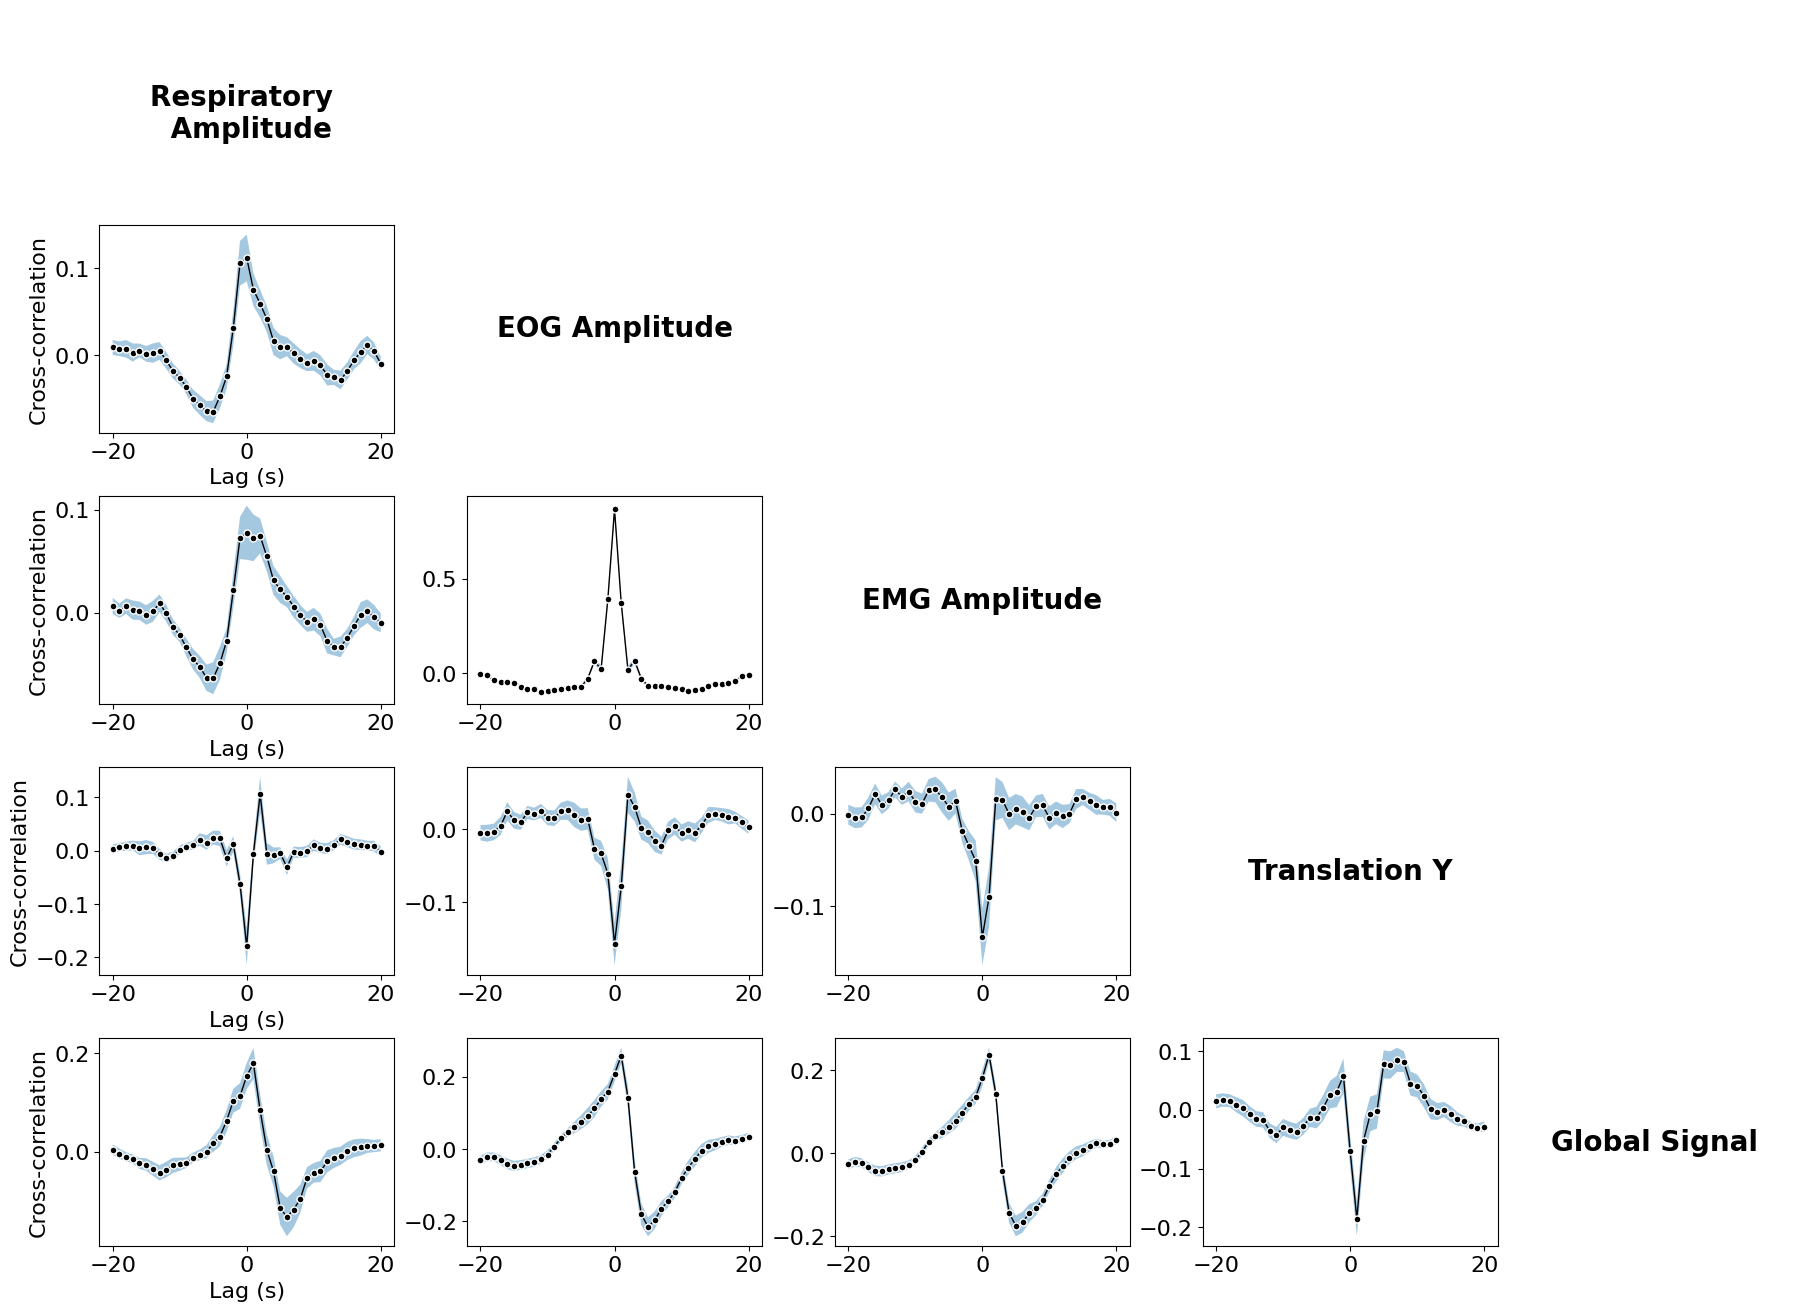

In [6]:
%matplotlib inline
# define physio labels in plot
physio_labels = [
    'resp_amp',
    'eog_mean',
    'emg_mean',
    'trans_y',
    'global_signal'
]

label_map = {
    'eog_mean': 'EOG Amplitude',
    'emg_mean': 'EMG Amplitude',
    'resp_amp': 'Respiratory \n Amplitude',
    'trans_y': 'Translation Y',
    'global_signal': 'Global Signal'
}

# construct bootstrap cross-correlation samples
n_samples = 500
n_lags = 20
# get subject session list
subject_session_list = list(loader.iter)
# generate 500 bootstrap samples
bootstrap_samples = _generate_bootstrap_samples(
    subject_session_list, 
    n_bootstrap=n_samples
)
# loop through bootstrap samples and calculate cross-correlation between 
# all physio labels
# initialize empty dict to store cross-correlation results
cc_results = {
    px: {py: [] for py in physio_labels} 
    for px in physio_labels
}
for i, sample in enumerate(bootstrap_samples):
    if i % 100 == 0:
        print(f'Bootstrap sample {i+1} of {len(bootstrap_samples)}')
    data_out = _concat_bootstrap_samples(
        sample, subject_session_list, data['physio']
    )
    for i in range(len(physio_labels)):
        for j in range(len(physio_labels)):
            if i > j:
                # if respiratory amplitude, there was periods of signal
                # loss, so we need to use sample weights to account for this
                if physio_labels[i] == 'resp_amp':
                    weights = data_out['weight']
                else:
                    weights = None
                cc = cross_corr(
                    x=data_out[physio_labels[i]],
                    y=data_out[physio_labels[j]],
                    w=weights,
                    lags=n_lags
                )
                cc_results[physio_labels[i]][physio_labels[j]].append(cc)

# plot physio labels
fig, axs = plt.subplots(
    nrows=5, ncols=5, layout='constrained',
    figsize=(18, 13)
)
for i in range(len(physio_labels)):
    for j in range(len(physio_labels)):
        if i > j: # cross-correlation
            # get mean and std of cross-correlation
            cc_mean = np.mean(
                cc_results[physio_labels[i]][physio_labels[j]],
                axis=0
            )
            cc_std = np.std(
                cc_results[physio_labels[i]][physio_labels[j]],
                axis=0
            )
            axs[i, j].plot(
                np.arange(-n_lags, n_lags+1),
                cc_mean,
                color='black',
                linewidth=1,
                marker='o',
                markersize=5,
                markeredgecolor='white',
                markerfacecolor='black',
                markeredgewidth=1,
            )
            axs[i, j].fill_between(
                np.arange(-n_lags, n_lags+1),
                cc_mean - cc_std,
                cc_mean + cc_std, 
                alpha=0.4
            )
            axs[i,j].tick_params(axis='both', which='major', labelsize=16)
            if j == 0:
                axs[i, j].set_xlabel('Lag (s)', fontsize=16)
                axs[i, j].set_ylabel('Cross-correlation', fontsize=16)

        if i == j: # physio title
            axs[i, j].text(
                0.5, 0.5, f'{label_map[physio_labels[i]]}',
                ha='center', va='center',
                fontsize=20,
                fontweight='bold'
            )
            axs[i, j].set_axis_off()
        if i < j: # off
            axs[i, j].set_axis_off()

plt.show()

# Head Motion and EEG Power at Respiratory Amplitude Peaks

## Find Respiratory Amplitude Peaks

In [7]:
import numpy as np
from scan.io.load import DatasetLoad # type: ignore
from scan.model.avg import EventFinder

# initialize dataset loader
loader = DatasetLoad(
    'vanderbilt'
)
# initialize dictionary to store peaks
subj_ses_peaks = {}
# iterate over subjects and sessions to find peaks
for subj, ses in loader.iter:
    data, _= loader.load_scan(
        subj, ses, 
        data='physio',
        physio_high_pass=True,
        norm='zscore'
    )
    # find peaks of resp amplitude
    event_finder = EventFinder(
        height=1,
        distance=10
    )
    events = event_finder.find_events(
        signals={
            'resp_amp': np.squeeze(data['physio']['resp_amp'])
        }
    )
    subj_ses_peaks[subj, ses] = events.events['resp_amp']



## Average Head Motion around Peaks

Bootstrap sample 1 of 500
Bootstrap sample 101 of 500
Bootstrap sample 201 of 500
Bootstrap sample 301 of 500
Bootstrap sample 401 of 500


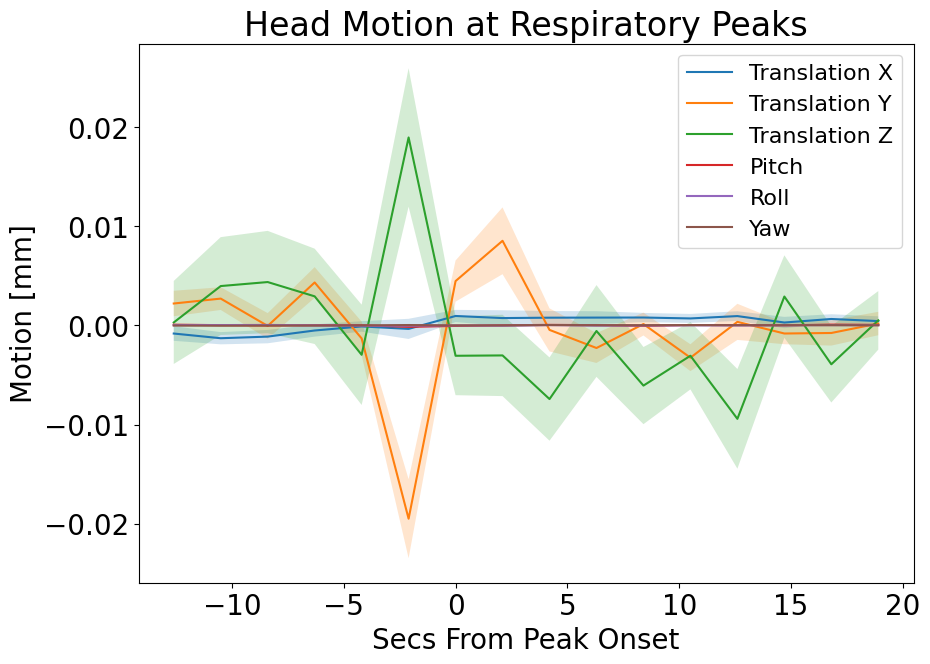

In [8]:
%matplotlib inline

import json

import matplotlib.pyplot as plt

from scan.model.avg import extract_range # type: ignore
from scan.preprocess.pipeline import FileMapper
from scan.preprocess.fsl import load_fsl_motion_params
from scan.io.utils import filter

from main import _generate_bootstrap_samples


# set event duration of 'peak' in seconds
EVENT_DUR = 10

# shift left peaks by 5 seconds to capture pre-peak activity
SHIFT_LEFT = 5

# Specify upper and lower limits of frequency range
freqs = np.linspace(2,20,30)

# load parameters for vanderbilt dataset
with open('scan/meta/params.json', 'rb') as f:
    params = json.load(f)['vanderbilt']

# get file paths to .mat eeg data
file_mapper = FileMapper(
    dataset='vanderbilt',
    params=params
)
file_paths = file_mapper.map()

# get subject session list
subject_session_list = list(loader.iter)
# initialize dictionary to store motion data for each subject and session
subj_ses_motion = {
    'trans_x': {subj_ses: [] for subj_ses in subject_session_list},
    'trans_y': {subj_ses: [] for subj_ses in subject_session_list},
    'trans_z': {subj_ses: [] for subj_ses in subject_session_list},
    'pitch': {subj_ses: [] for subj_ses in subject_session_list},
    'roll': {subj_ses: [] for subj_ses in subject_session_list},
    'yaw': {subj_ses: [] for subj_ses in subject_session_list}
}
labels = {
    'trans_x': 'Translation X',
    'trans_y': 'Translation Y',
    'trans_z': 'Translation Z',
    'pitch': 'Pitch',
    'roll': 'Roll',
    'yaw': 'Yaw',
}

# iterate over subjects and sessions, load .mat eeg data
for subj, ses in loader.iter:
    # load .par motion file
    motion = load_fsl_motion_params(file_paths['physio'][subj][ses]['raw']['motion'])
    # filter motion data
    motion = {
        m: filter(motion[m], high_pass=True, low_pass=False, tr=2.1) 
        for m in motion
    }    
    # get joint peaks of resp amplitude
    peaks = subj_ses_peaks[subj, ses]
    # extract motion data for each peak
    for m in motion:
        motion_data = motion[m][:, np.newaxis]
        motion_peaks = []
        # index windows for each marker
        for center in peaks:
            subj_ses_motion[m][subj, ses].append(
                extract_range(motion_data, center, -SHIFT_LEFT, EVENT_DUR)
            )

# generate 500 bootstrap samples
bootstrap_samples = _generate_bootstrap_samples(
    subject_session_list, 
    n_bootstrap=500
)

# loop through bootstrap sample and calculate average motion at peaks
bootstrap_motion = {
    'trans_x': [],
    'trans_y': [],
    'trans_z': [],
    'pitch': [],
    'roll': [],
    'yaw': []
}

for i, sample in enumerate(bootstrap_samples):
    if i % 100 == 0:
        print(f'Bootstrap sample {i+1} of {len(bootstrap_samples)}')
    # loop through motion labels and calculate average of motion at peaks
    for m in labels.keys():
        motion_data = [
             peak_data for subj, ses in sample
             for peak_data in subj_ses_motion[m][subj, ses]
        ]
        bootstrap_motion[m].append(np.nanmean(motion_data, axis=0))

# get mean and std of motion at peaks
bootstrap_motion_mean = {
    m: np.squeeze(np.nanmean(bootstrap_motion[m], axis=0)) 
    for m in labels.keys()
}
bootstrap_motion_std = {
    m: np.squeeze(np.nanstd(bootstrap_motion[m], axis=0)) 
    for m in labels.keys()
}
# create figure
fig, ax = plt.subplots(figsize=(10,7))
ax.set_title('Head Motion at Respiratory Peaks', fontsize=24)
ax.set_xlabel('Secs From Peak Onset', fontsize=20)
ax.set_ylabel('Motion [mm]', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=20)
time = np.arange(-SHIFT_LEFT-1, EVENT_DUR)*2.1
for m in labels.keys():
    ax.plot(time, bootstrap_motion_mean[m], label=labels[m])
    ax.fill_between(
        time, 
        bootstrap_motion_mean[m] - bootstrap_motion_std[m], 
        bootstrap_motion_mean[m] + bootstrap_motion_std[m], 
        alpha=0.2
    )
ax.legend(fontsize=16)

plt.show()

## EEG Power at Peaks

/var/folders/x9/qzst2v3x2ld1v31y4m1b7j0c0000gp/T/ipykernel_36514/3917592686.py:64: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  eeg_raw.set_annotations(event_annot)
/var/folders/x9/qzst2v3x2ld1v31y4m1b7j0c0000gp/T/ipykernel_36514/3917592686.py:64: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  eeg_raw.set_annotations(event_annot)
/var/folders/x9/qzst2v3x2ld1v31y4m1b7j0c0000gp/T/ipykernel_36514/3917592686.py:64: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  eeg_raw.set_annotations(event_annot)
/var/folders/x9/qzst2v3x2ld1v31y4m1b7j0c0000gp/T/ipykernel_36514/3917592686.py:64: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  eeg_raw.set_annotations(event_annot)
/var/folders/x9/qzst2v3x2ld1v31y4m1b7j0c0000gp/T/ipykernel_36514/3917592686.py:64: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  eeg_raw

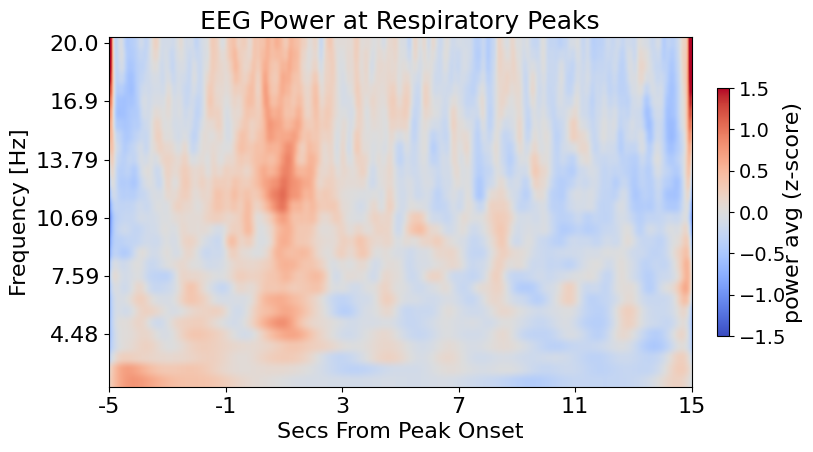

In [10]:
%matplotlib inline
import json

import matplotlib.pyplot as plt
import mne
import pandas as pd

from mne.time_frequency import tfr_morlet
from scipy.io import loadmat

from scan.preprocess.pipeline import FileMapper
from scan.preprocess.dataset import VANDERBILT_EEG_CHAN_LABELS

# set event duration of 'peak' in seconds
EVENT_DUR = 20

# shift left peaks by 5 seconds to capture pre-peak activity
SHIFT_LEFT = 5

# Specify upper and lower limits of frequency range
freqs = np.linspace(2,20,30)

# load parameters for vanderbilt dataset
with open('scan/meta/params.json', 'rb') as f:
    params = json.load(f)['vanderbilt']

# get file paths to .mat eeg data
file_mapper = FileMapper(
    dataset='vanderbilt',
    params=params
)
file_paths = file_mapper.map()

# initialize dictionary to store power data
subj_ses_power = []

# iterate over subjects and sessions, load .mat eeg data
for subj, ses in loader.iter:
    # load .mat eeg data
    eeg_mat = loadmat(file_paths['physio'][subj][ses]['raw']['eeg'], squeeze_me=True)
    # extract eeg data and sampling frequency
    eeg_data = eeg_mat['EEG']['data'].item()
    sf_eeg = eeg_mat['EEG']['srate'].item()
    chan_labels = [chan[0] for chan in eeg_mat['EEG']['chanlocs'].item()]
    # extract indices of vanderbilt channels
    eeg_chan_idx = [chan_labels.index(chan) for chan in VANDERBILT_EEG_CHAN_LABELS]
    # extract eeg data for vanderbilt channels
    eeg_data = eeg_data[eeg_chan_idx, :]
    # create mne raw object
    info = mne.create_info(
        VANDERBILT_EEG_CHAN_LABELS, ch_types='eeg', sfreq=sf_eeg
    )
    eeg_raw = mne.io.RawArray(eeg_data, info, verbose=False)
    # resample to 100 Hz
    eeg_raw.resample(100)
    # trim off 14.7s to match trim of functional data
    eeg_raw.crop(tmin=14.7)
    # get peaks of resp amplitude
    peaks = subj_ses_peaks[subj, ses]
    # get first onset of peaks in seconds
    peaks = [(p * params['func']['tr']) - SHIFT_LEFT for p in peaks]
    # Annotate raw MNE obj
    event_annot = mne.Annotations(onset=peaks, duration=EVENT_DUR, description='PEAK')
    eeg_raw.set_annotations(event_annot)
    events_mne, event_annot = mne.events_from_annotations(eeg_raw, verbose=False)
    # check if there are any events
    if len(events_mne) == 0:
        print(f'No events found for subject {subj}, session {ses}. Skipping...')
        continue
    epochs = mne.Epochs(
        eeg_raw, events_mne, 1, 0, EVENT_DUR, 
        baseline = None, verbose=False
    )
    n_cycles = 15 # number of cycles parameter for wavelet
    # Morlet wavelet evoked power average
    power_avg = epochs.compute_tfr(
        method='morlet',
        freqs=freqs,
        n_cycles=n_cycles,
        return_itc=False,
        average=True,
        verbose=False
    )
    ch_names = power_avg.ch_names
    # z-score power time courses
    power_avg.apply_baseline(baseline=(None, None), mode='zscore', verbose=False)
    # Convert to Pandas dataframe for further processing
    power_df = power_avg.to_data_frame(index=None)
    power_df['avg_chan'] = power_df[ch_names].mean(axis=1)
    power_df['freq_indx'] = power_df.groupby('freq').transform('cumcount')
    power_df['subj'] = f'{subj}_{ses}'
    # store power data
    subj_ses_power.append(
        power_df[['subj', 'time','freq','freq_indx', 'avg_chan']].copy()
    )

# Concatenate subject evoked power averages across subjects
power_group = pd.concat(subj_ses_power, axis=0)

# Across-subject evoked power average
power_group_avg = power_group.groupby(['freq', 'freq_indx'])['avg_chan'].mean()
power_group_avg = power_group_avg.unstack().values

# Plot 
fig, ax = plt.subplots(figsize=(8,5))
ax.set_title('EEG Power at Respiratory Peaks', fontsize=18)
im = ax.imshow(power_group_avg[::-1, :], aspect=40,  cmap='coolwarm', 
               vmin=-1.5, vmax=1.5)
times = power_avg.times - SHIFT_LEFT
t_sample = np.arange(0, len(times), 400)
ax.set_xticks(t_sample)
ax.set_xticklabels(times[t_sample].astype('int'))
ax.set_xlabel('Secs From Peak Onset', fontsize=16)

freq_sample = np.arange(0,len(freqs),5)
ax.set_yticks(freq_sample)
ax.set_yticklabels(np.round(freqs[::-1][freq_sample],2))
ax.set_ylabel('Frequency [Hz]', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=16)
cbar = plt.colorbar(im,fraction=0.02, pad=0.04)
cbar.ax.tick_params(labelsize=14)
cbar.set_label('power avg (z-score)', fontsize=16, labelpad=-2)
